DIR1: /Users/vinhlongha/Research/EEW/input/2025_ML_VN/input_data/20180812174454_ML5.1/20180812174454_VN_DBVB_HHZ.SAC
DIR2: /Users/vinhlongha/Research/EEW/input/Data_vres_fixed_name/20180812_174423_M5.1/DBVB.HHZ..SAC


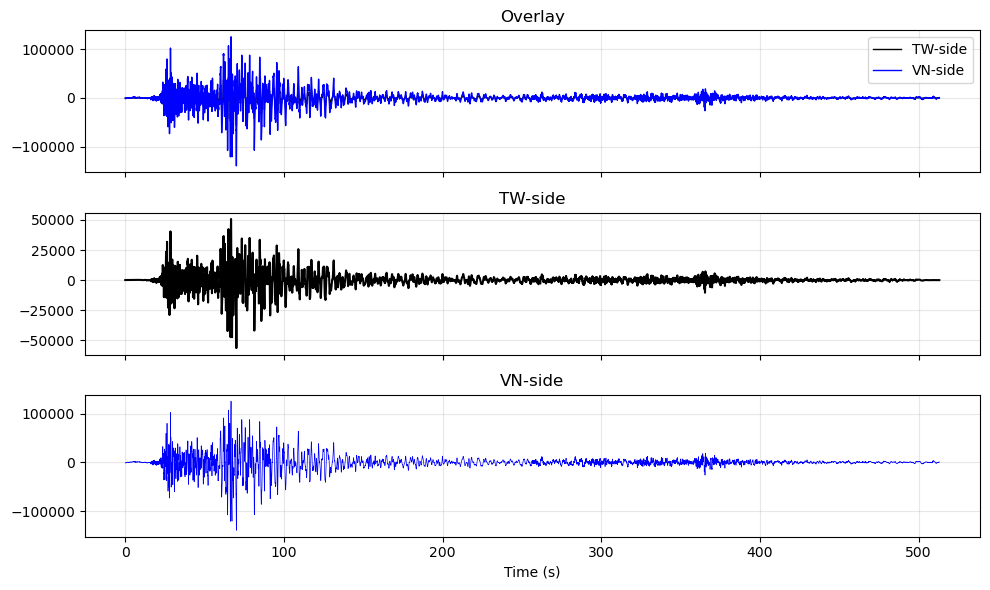

In [5]:
from obspy import read
from pathlib import Path
import matplotlib.pyplot as plt

DIR1 = "/Users/vinhlongha/Research/EEW/input/2025_ML_VN/input_data/20180812174454_ML5.1"
DIR2 = "/Users/vinhlongha/Research/EEW/input/Data_vres_fixed_name/20180812_174423_M5.1"

STA = "DBVB"   # <<< change here
CHA = "HHZ"    # <<< change here

def find_trace(directory, sta, cha):
    for f in Path(directory).glob("*.SAC"):
        try:
            tr = read(str(f))[0]
            if tr.stats.station == sta and tr.stats.channel == cha:
                return f, tr
        except:
            continue
    return None, None


f1, tr1 = find_trace(DIR1, STA, CHA)
f2, tr2 = find_trace(DIR2, STA, CHA)

print("DIR1:", f1)
print("DIR2:", f2)

if tr1 is None or tr2 is None:
    print("❌ Not found in one of the directories")

else:
    # cut to overlap
    t0 = max(tr1.stats.starttime, tr2.stats.starttime)
    t1 = min(tr1.stats.endtime, tr2.stats.endtime)

    tr1 = tr1.copy().trim(t0, t1)
    tr2 = tr2.copy().trim(t0, t1)

    # detrend
    tr1.detrend("demean")
    tr2.detrend("demean")

    # time axis
    t = tr1.times()
    
    fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    
    # --- 1. overlay ---
    axs[0].plot(t, tr1.data, 'k', lw=1.0, label='TW-side')
    axs[0].plot(t, tr2.data, 'b', lw=1.0, label='VN-side')
    axs[0].set_title("Overlay")
    axs[0].legend()
    axs[0].grid(alpha=0.3)
    
    # --- 2. trace 1 ---
    axs[1].plot(t, tr1.data, 'k', lw=1.5)
    axs[1].set_title("TW-side")
    axs[1].grid(alpha=0.3)
    
    # --- 3. trace 2 ---
    axs[2].plot(t, tr2.data, 'b', lw=0.5)
    axs[2].set_title("VN-side")
    axs[2].grid(alpha=0.3)
    
    axs[2].set_xlabel("Time (s)")
    
    plt.tight_layout()
    plt.show()